In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
dataset = pd.read_csv("car_purchasing.csv",encoding='latin-1')
dataset.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [5]:
dataset.isnull().sum()

customer name          0
customer e-mail        0
country                0
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64

In [6]:
#EDA
# customer name , customer e-mail & country are not a good decision factor here 
dataset.drop(["customer name","customer e-mail","country"],axis=1,inplace=True)
dataset.head()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


#### Let's see the heatmap to see the correlation b/w features

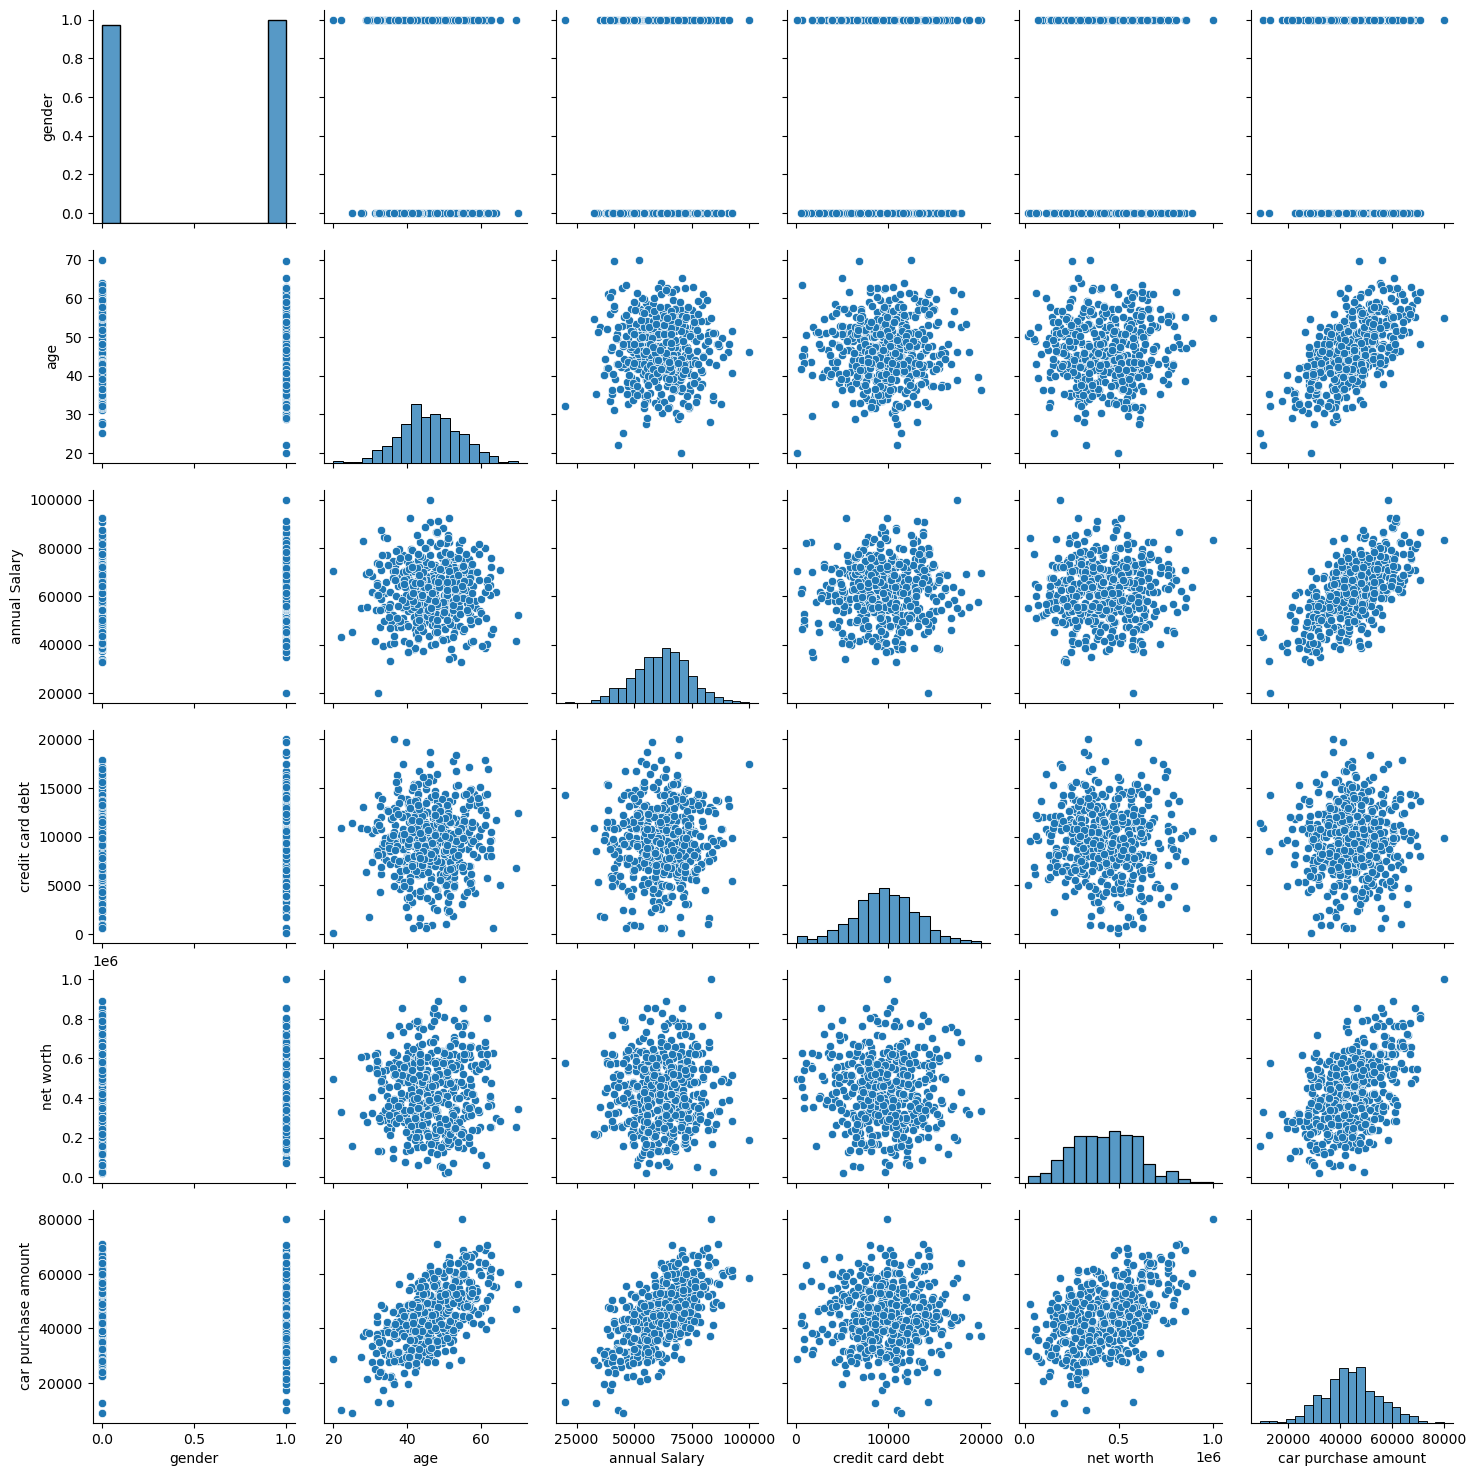

In [7]:
sns.pairplot(data=dataset)

Upon seeing the pair plot we can see that gender also doesn't form a linearity with the car purchase amount. So let's drop gender as well

In [8]:
dataset.drop("gender",axis=1,inplace=True)
dataset.head()

,age,annual Salary,credit card debt,net worth,car purchase amount
0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [9]:
X = dataset.drop("car purchase amount",axis=1).values
y = dataset["car purchase amount"].values
print(X)
print(y)

[[4.18517198e+01 6.28120930e+04 1.16093809e+04 2.38961250e+05]
 [4.08706234e+01 6.66468929e+04 9.57295714e+03 5.30973908e+05]
 [4.31528975e+01 5.37985511e+04 1.11603551e+04 6.38467177e+05]
 ...
 [5.39434972e+01 6.88887780e+04 1.06116069e+04 7.64531320e+05]
 [5.91605086e+01 4.98119906e+04 1.40130345e+04 3.37826638e+05]
 [4.67311525e+01 6.13706777e+04 9.39134163e+03 4.62946492e+05]]
[35321.45877 45115.52566 42925.70921 67422.36313 55915.46248 56611.99784
 28925.70549 47434.98265 48013.6141  38189.50601 59045.51309 42288.81046
 28700.0334  49258.87571 49510.03356 53017.26723 41814.72067 43901.71244
 44633.99241 54827.52403 51130.95379 43402.31525 47240.86004 46635.49432
 45078.40193 44387.58412 37161.55393 49091.97185 58350.31809 43994.35972
 17584.56963 44650.36073 66363.89316 53489.46214 39810.34817 51612.14311
 38978.67458 10092.22509 35928.52404 54823.19221 45805.67186 41567.47033
 28031.20985 27815.73813 68678.4352  68925.09447 34215.7615  37843.46619
 37883.24231 48734.35708 27187.2

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=1)

In [11]:
X_train.var(axis=0)

array([6.46630062e+01, 1.28359396e+08, 1.21501000e+07, 2.96694795e+10])

In [12]:
X_test.var(axis=0)

array([6.01149592e+01, 1.61674817e+08, 1.19049168e+07, 3.08935319e+10])

In [13]:
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [14]:
regressor.score(X_test,y_test)

0.9999999747740989

In [15]:
predictions = regressor.predict(X_test)
predictions

array([22090.52190695, 23519.21664426, 37843.66389037, 43680.1874022 ,
       53112.17344492, 47443.13458881, 51868.15325839, 44649.40265768,
       46133.78999906, 38951.69236322, 59621.60614175, 36110.39835271,
       34518.635657  , 48103.34424547, 40020.13469804, 46379.64125035,
       55420.09068333, 70879.48675737, 44419.03137813, 38505.223919  ,
       44734.99077369, 39889.24046554, 35716.59656326, 60117.367422  ,
       52952.64243674, 63081.63798213, 39810.3624912 , 59095.1002992 ,
       57430.60746819, 43264.67541148, 30720.97645326, 56067.0409758 ,
       58234.98813354, 42703.55627301, 46400.6987753 , 52665.70241947,
       59483.94451033, 55913.0114347 , 43241.79962038, 46084.36920065,
       36545.79673114, 32060.9741978 , 27588.59460051, 44577.21613171,
       31087.2032286 , 31528.17442596, 28439.88630737, 30734.51462264,
       44361.25824109, 33637.60690524, 42481.17674242, 37742.13977309,
       56613.04481436, 40590.77715328, 27300.88263838, 49729.67153741,
      

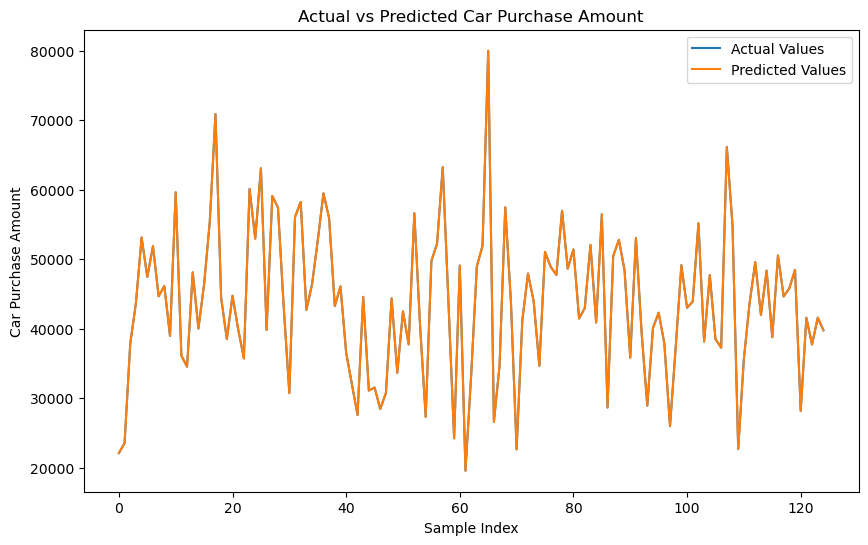

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Values')
plt.plot(predictions, label='Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Car Purchase Amount')
plt.title('Actual vs Predicted Car Purchase Amount')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import mean_squared_error

# Check the errors 
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 2.869816400318867


In [18]:
X_test[0]

array([3.53929182e+01, 4.70541425e+04, 7.23467209e+03, 2.75762484e+05])

In [19]:
car_spend = regressor.predict(np.array([[53, 72000, 15000, 100000]]))
car_spend

array([45841.77031199])

#### Let's export our model as pkl

In [20]:
import joblib
joblib.dump(regressor,"regressor.pkl")

['regressor.pkl']

In [21]:
import sys

print(sys.version)

3.13.2 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:35) [Clang 14.0.6 ]
